Samara Wardasadiya (F1D02410023)

In [2]:
import numpy as np  
import matplotlib.pyplot as plt
import cv2 as cv

from pcdlib import manimg as img
from pcdlib import manhist as hist
from pcdlib import pcdlib as lib
# from pcdlib import asis as asis

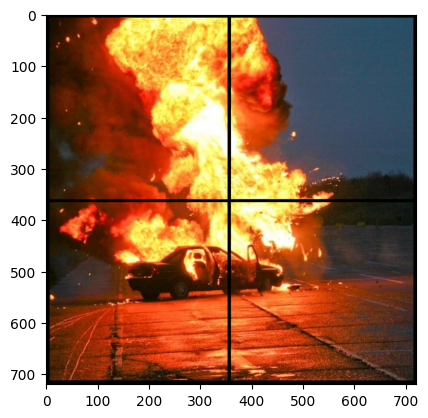

In [3]:
baca = cv.imread('Assets/Meledak.png')
boom = cv.cvtColor(baca, cv.COLOR_BGR2RGB)
plt.imshow(boom, cmap="gray")

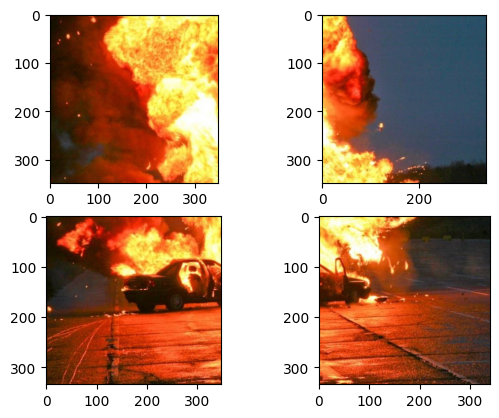

In [4]:
# slice
h, w, d = boom.shape
boom1 = boom[5:353, 5:353]
boom2 = boom[5:353, 360:700]
boom3 = boom[366:700, 5:353]
boom4 = boom[366:700, 360:700]

plt.subplot(2,2,1)
plt.imshow(boom1, cmap="gray")
plt.subplot(2,2,2)
plt.imshow(boom2, cmap="gray")
plt.subplot(2,2,3)
plt.imshow(boom3, cmap="gray")
plt.subplot(2,2,4)
plt.imshow(boom4, cmap="gray")

In [5]:
def merge_image(citra1, citra2, orientation='H'): 
    if orientation == 'H':   
        tinggi = max(citra1.shape[0], citra2.shape[0]) 
        lebar_total = citra1.shape[1] + citra2.shape[1] 
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi, lebar_total), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi, lebar_total, citra1.shape[2]), dtype=citra1.dtype) 

        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[0:citra2.shape[0], citra1.shape[1]:citra1.shape[1]+citra2.shape[1]] = citra2 

    else:   
        tinggi_total = citra1.shape[0] + citra2.shape[0] 
        lebar = max(citra1.shape[1], citra2.shape[1]) \
        
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi_total, lebar), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi_total, lebar, citra1.shape[2]), dtype=citra1.dtype) 

        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        
        gabungan[citra1.shape[0]:citra1.shape[0]+citra2.shape[0], 0:citra2.shape[1]] = citra2 
            
    return gabungan

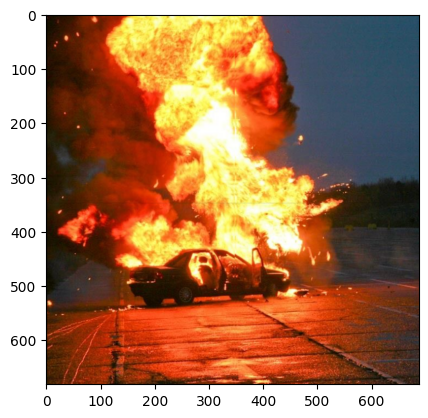

In [6]:
# gabung

atas = merge_image(boom1, boom2, 'H')
bawah = merge_image(boom3, boom4, 'H')

jadi = merge_image(atas, bawah, 'V')
# plt.imshow(atas, cmap="gray")
# plt.imshow(bawah, cmap="gray")
plt.imshow(jadi, cmap="gray")

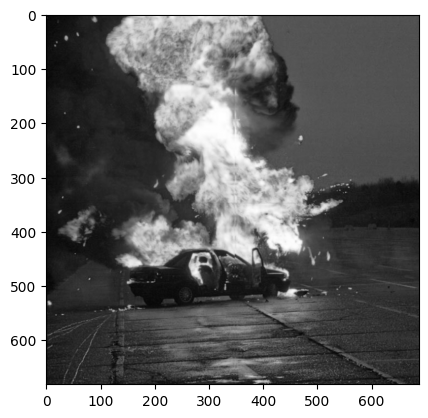

In [7]:
gray = img.to_grayscale(jadi)
plt.imshow(gray, cmap="gray")

In [8]:
def ekualisasi(citra):

    height, width = citra.shape

    # Histogram
    hist = np.zeros(256, dtype=int)

    # Hitung histogram citra
    for i in range(height):
        for j in range(width):

            pixel = citra[i, j]
            hist[pixel] += 1

    # CDF
    cdf = np.zeros(256, dtype=int)

    cdf[0] = hist[0]

    # Hitung CDF
    for i in range(1, 256):

        cdf[i] = cdf[i - 1] + hist[i]

    # Normalisasi CDF
    cdf_normal = np.round(cdf * 255 / (height * width)).astype(np.uint8)

    # Hasil ekualisasi
    hasil = np.zeros_like(citra, dtype=np.uint8)

    # Terapkan hasil CDF normalisasi
    for i in range(height):
        for j in range(width):

            pixel = citra[i, j]
            hasil[i, j] = cdf_normal[pixel]

    return hasil

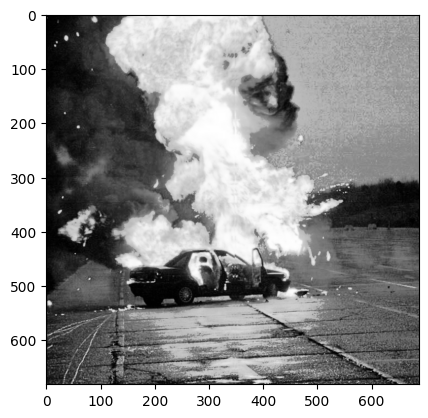

In [9]:
equal = ekualisasi(gray)
plt.imshow(equal, cmap="gray")


In [10]:
def buat_hist(citra): 
    histogram = [0] * 256 
    height = len(citra) 
    width = len(citra[0]) if height > 0 else 0 
    for i in range(height): 
        for j in range(width): 
            val = int(citra[i][j])   
            histogram[val] += 1   
    return histogram 

def plot_histogram(histogram, title, ImgColor): 
    plt.figure(figsize=(10, 5)) 
    plt.xlabel("Intensitas Piksel") 
    plt.title(title) 
    plt.ylabel("Jumlah Piksel") 
    plt.bar(range(256), histogram, color=ImgColor, width=0.8) 
    plt.show()

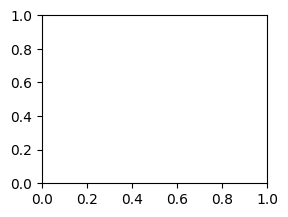

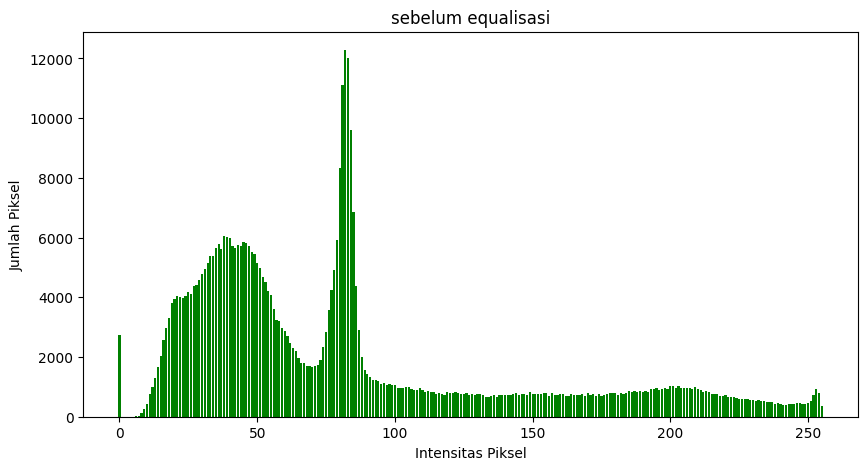

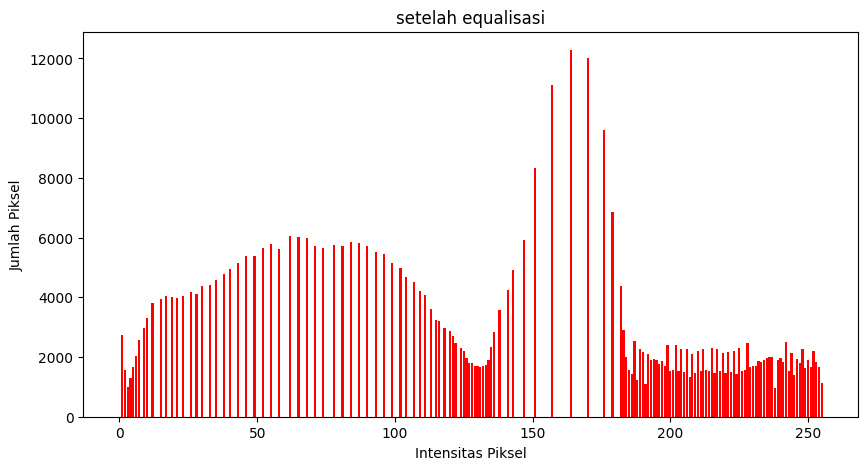

In [11]:
# tampilin histogram gabungan

histo1 = buat_hist(gray)
histo2 = buat_hist(equal)

plt.subplot(2,2,1)
plot_histogram(histo1, "sebelum equalisasi", "green")
plot_histogram(histo2, "setelah equalisasi", "red")


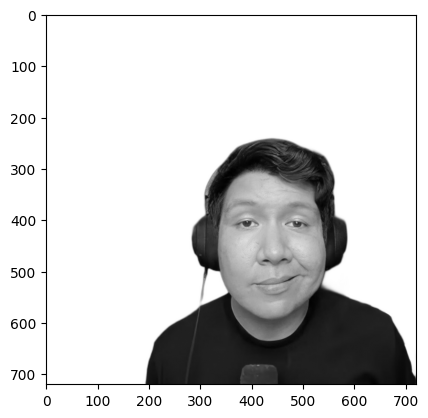

In [12]:
ambil = cv.imread('Assets/Windut.png')
windut = cv.cvtColor(ambil, cv.COLOR_BGR2GRAY)
plt.imshow(windut, cmap="gray")

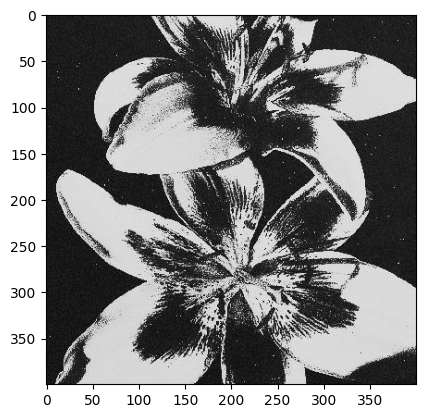

In [13]:
take = cv.imread('Assets/Bunga.png')
bunga = cv.cvtColor(take, cv.COLOR_BGR2GRAY)
plt.imshow(bunga, cmap="gray")

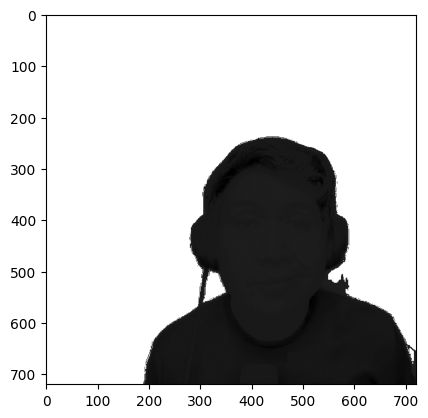

In [14]:
spesi = lib.specification_gray_to_gray(windut, bunga)
plt.imshow(spesi, cmap="gray")

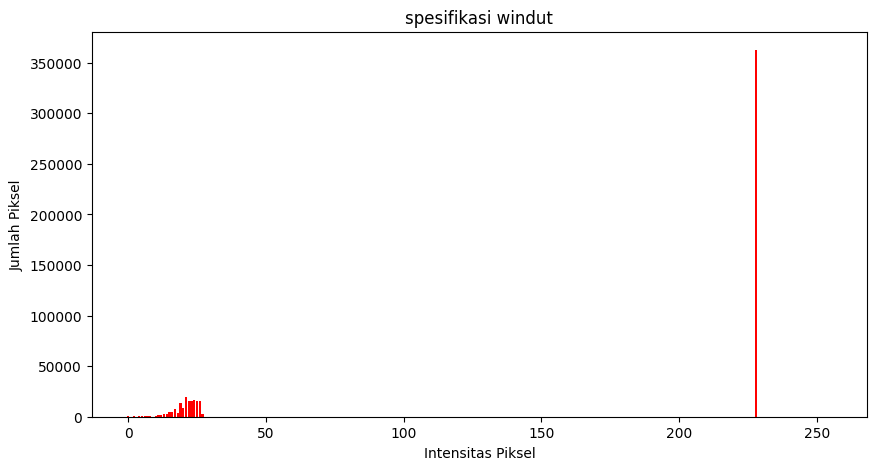

In [15]:
histoWindut = buat_hist(spesi)
plot_histogram(histoWindut, "spesifikasi windut", "red")

In [16]:
print(jadi.shape)

(682, 688, 3)


In [17]:
print(windut.shape)

(720, 720)


Text(0.5, 1.0, 'Masking Background')

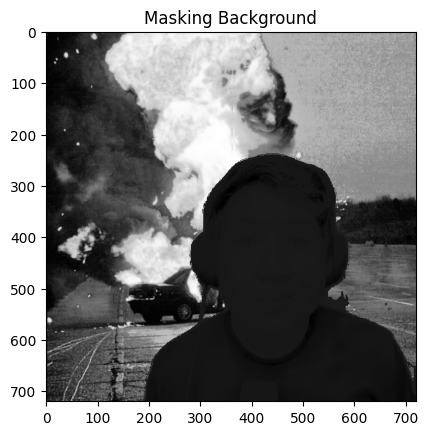

In [27]:
# resize biar sama
bg = cv.resize(equal, (spesi.shape[1], spesi.shape[0]))

masking = np.zeros_like(windut)

for i in range(spesi.shape[0]):
    for j in range(spesi.shape[1]):
        if spesi[i, j] > 227:  # threshold bisa disesuaikan
            masking[i, j] = bg[i, j]
        else:
            masking[i, j] = spesi[i, j]

plt.imshow(masking, cmap='gray')
plt.title("Masking Background")

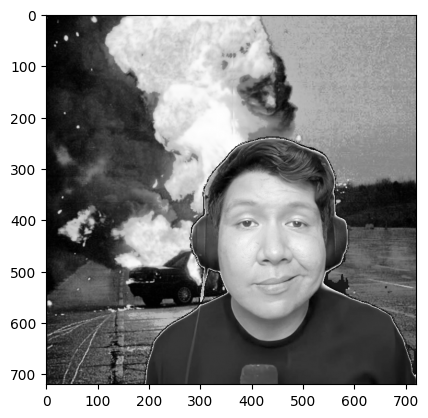

In [28]:
akhir = masking + windut

plt.imshow(akhir, cmap="gray")

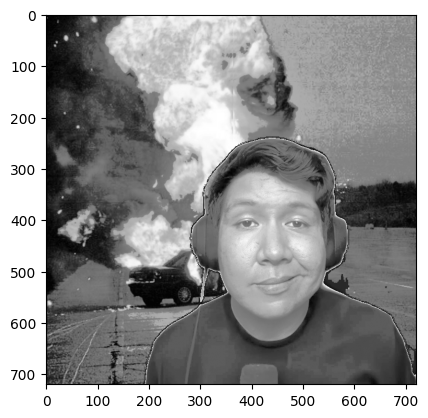

In [36]:
# spesifikasi akhir
taulah = cv.imread('Assets/Langit.png')
langit = cv.cvtColor(taulah, cv.COLOR_BGR2GRAY)
# plt.imshow(langit, cmap="gray")
spe_akhir = hist.spesifikasi_histogram(akhir, langit)
plt.imshow(spe_akhir, cmap="gray")


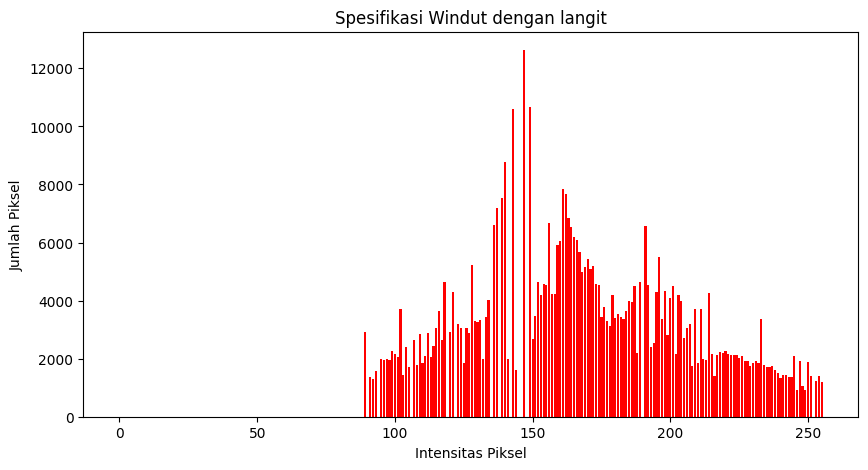

In [37]:
last = buat_hist(spe_akhir)
plot_histogram(last, "Spesifikasi Windut dengan langit", "red")

In [39]:
print(spe_akhir.shape)

(720, 720)


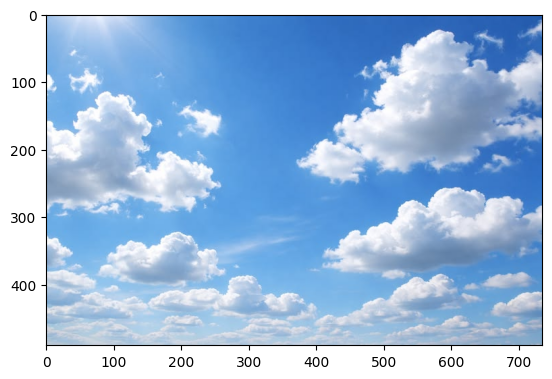

In [38]:
lagi = cv.imread('Assets/Langit.png')
langit_cerah = cv.cvtColor(taulah, cv.COLOR_BGR2RGB)
plt.imshow(langit_cerah, cmap="gray")

In [47]:
itu = langit_cerah[0:720, 0:720, 3]
hasil = langit_cerah + spe_akhir
plt.imshow(hasil, cmap="gray")

IndexError: index 3 is out of bounds for axis 2 with size 3

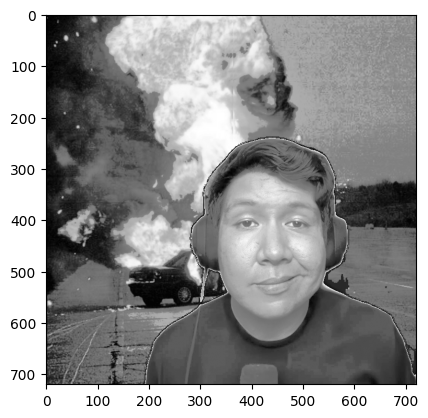

In [45]:
hasil = np.zeros_like(spe_akhir, dtype=int) 
for i in range(hasil.shape[0]): 
    for j in range(hasil.shape[1]): 
        if(spe_akhir[i,j]>50): 
            hasil[i,j] = spe_akhir[i,j] 
plt.imshow(hasil, cmap="gray") 

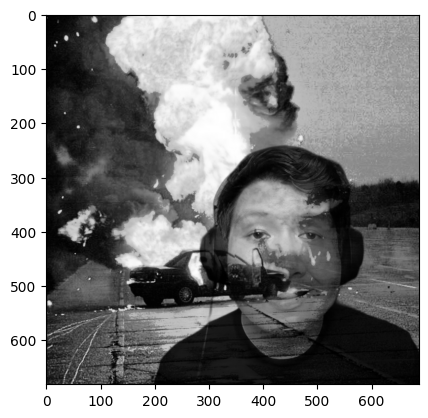

In [26]:
# resize
h, w, d = jadi.shape
newWindut = windut [0:682, 0:688]
masking = lib.masking_gray_to_gray(newWindut, equal)
plt.imshow(masking, cmap="gray")